# Análise de lives de jornalismo no YouTube — notebook 3

### Grupo:
- Janderson Pereira
- Walter
- Junior Fernandes Marques `N.USP 8129363`

### Introdução

Notebook complementa o N1 e implementa 7 novos insights num aprofundamento sobre os dados.
do notebook principal (`analise_lives_youtube_n1.ipynb`).

**Dependências:** `pandas`, `pyarrow`, `numpy`, `matplotlib`, `plotly` (opcional)
```
pip install pandas pyarrow numpy matplotlib plotly
```

In [1]:
import os, json, re, math, html
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

DATA_DIR = 'audiencia_export_2026-06-21_144011'

try:
    from zoneinfo import ZoneInfo
    TZ = ZoneInfo('America/Sao_Paulo')
except Exception:
    TZ = None

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .25, 'font.size': 11,
})
BLUE, AMBER, GRAY, RED, GREEN = '#2f6fb3', '#d28a18', '#8a8a8a', '#c0392b', '#27ae60'

def path(name):
    return os.path.join(DATA_DIR, name + '.parquet')

def load(name, **kw):
    return pd.read_parquet(path(name), **kw)

def to_dt(series_epoch_s):
    s = pd.to_datetime(series_epoch_s, unit='s', utc=True)
    return s.dt.tz_convert(TZ) if TZ else s

print('DATA_DIR =', os.path.abspath(DATA_DIR))

DATA_DIR = /home/junior_marqx27/Documents/infoVis/Trabalho/audiencia_export_2026-06-21_144011


In [2]:
channels = load('channels')
videos   = load('videos')
ccv      = load('ccv_history')

name_map = dict(zip(channels['handle'], channels['name']))
vid2ch   = dict(zip(videos['video_id'], videos['channel_handle']))

def ch_name(h):
    return name_map.get(h, h)

print(f'channels : {len(channels):>9,}')
print(f'videos   : {len(videos):>9,}')
print(f'ccv      : {len(ccv):>9,}')

channels :        12
videos   :     2,797
ccv      :   121,280


---
## Insight 1 — Correlação likes × audiência

`like_count` vs `concurrent_view_count` ao longo do tempo.
Canais com audiência alta e poucos likes podem ter público mais passivo;
canais com proporção alta de likes podem ter fãs mais engajados.

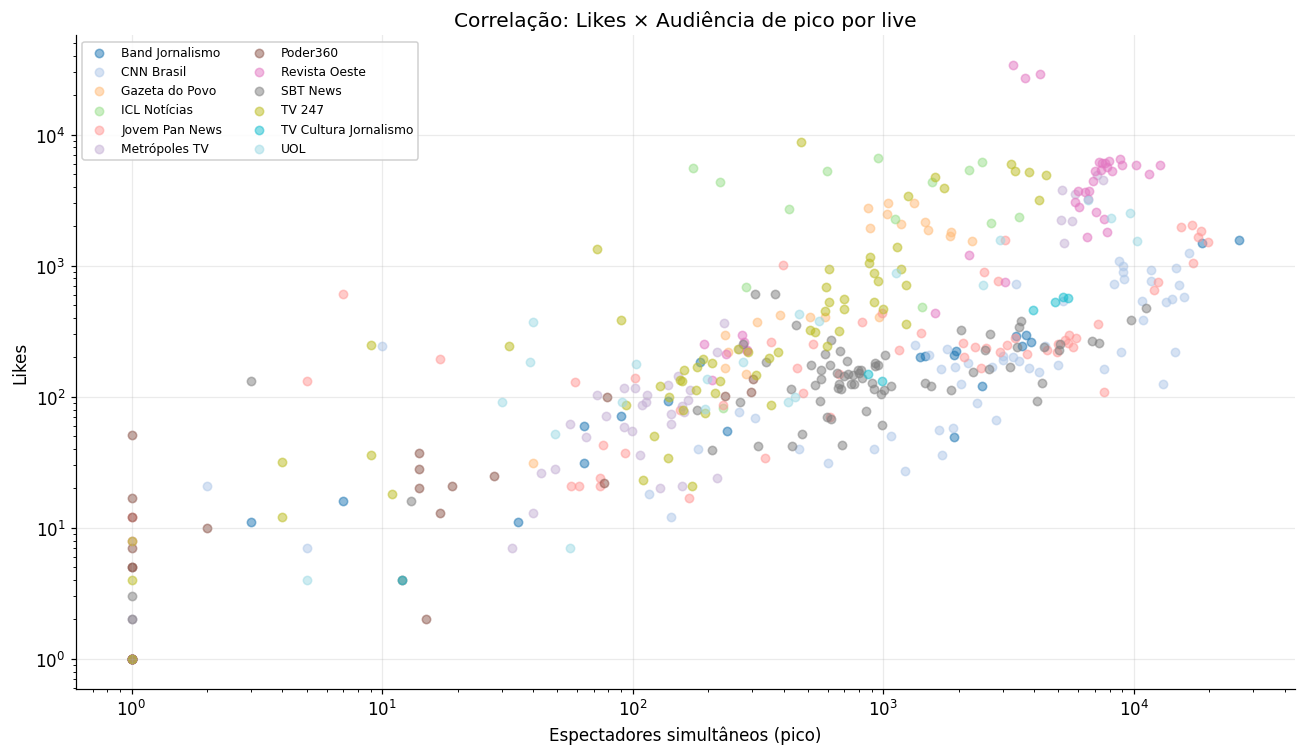


Taxa de likes (%) por canal:
                       taxa_likes_pct
canal                                
TV 247                          47.37
Metrópoles TV                   38.56
Gazeta do Povo                  21.21
Revista Oeste                   19.51
ICL Notícias                    18.66
UOL                             16.41
TV Cultura Jornalismo           12.18
Band Jornalismo                  9.39
Jovem Pan News                   6.46
Poder360                         5.97
CNN Brasil                       4.32
SBT News                         3.93


In [3]:
vv = videos[['video_id','channel_handle','like_count','concurrent_view_count','view_count']].copy()
vv['canal'] = vv['channel_handle'].map(name_map)
vv = vv.dropna(subset=['like_count','concurrent_view_count'])
vv = vv[(vv['like_count'] > 0) & (vv['concurrent_view_count'] > 0)]

fig, ax = plt.subplots(figsize=(12, 7))
canais_unicos = vv['canal'].unique()
cores = plt.cm.tab20(np.linspace(0, 1, len(canais_unicos)))

for i, canal in enumerate(sorted(canais_unicos)):
    sub = vv[vv['canal'] == canal]
    ax.scatter(sub['concurrent_view_count'], sub['like_count'],
               label=canal, alpha=0.5, s=30, color=cores[i])

ax.set_xlabel('Espectadores simultâneos (pico)')
ax.set_ylabel('Likes')
ax.set_title('Correlação: Likes × Audiência de pico por live')
ax.legend(fontsize=8, loc='upper left', ncol=2, framealpha=0.9)
ax.set_xscale('log'); ax.set_yscale('log')
plt.tight_layout(); plt.show()

# Taxa likes/views por canal
taxa = vv.groupby('canal').agg(
    likes=('like_count','sum'),
    views=('view_count','sum')
).assign(taxa_likes_pct=lambda d: (d['likes']/d['views']*100).round(2))
print('\nTaxa de likes (%) por canal:')
print(taxa[['taxa_likes_pct']].sort_values('taxa_likes_pct', ascending=False).to_string())

---
## Insight 2 — Retenção intra-live

Qual percentual da audiência de pico permanece até o fim da live?


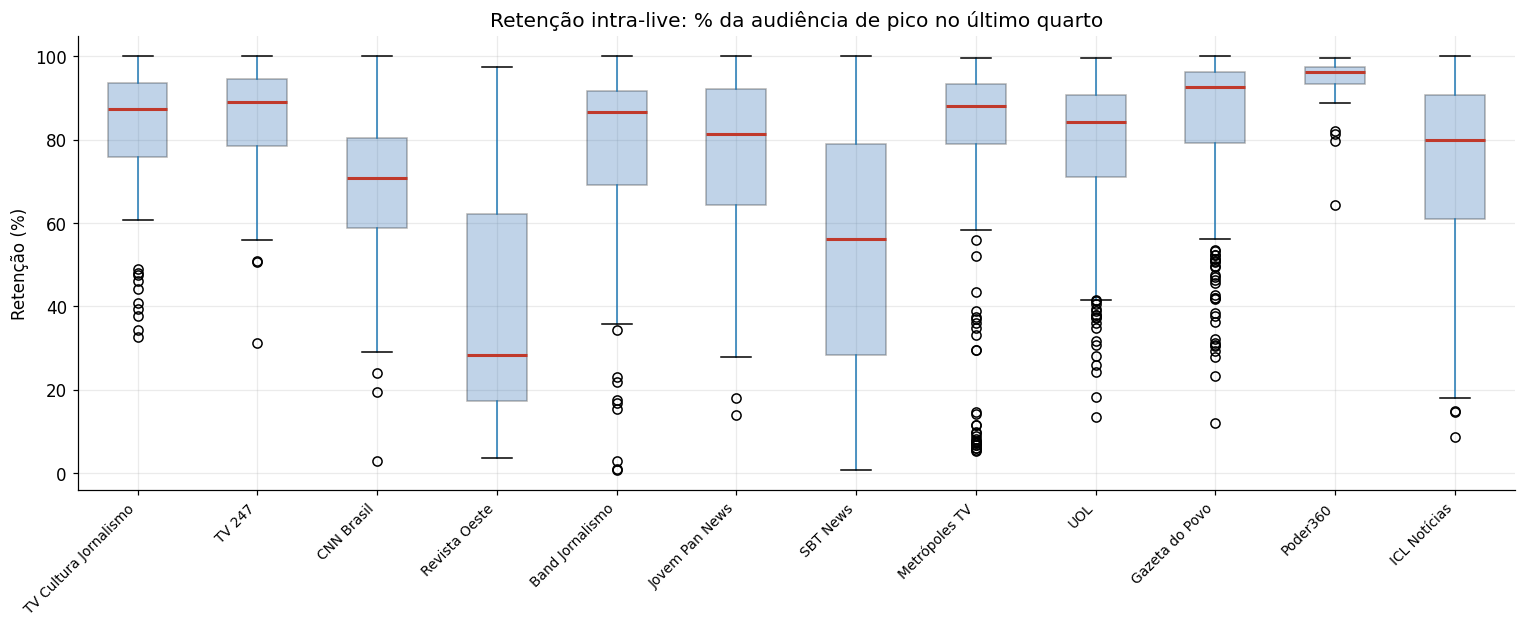


Retenção mediana por canal:
canal
TV Cultura Jornalismo    96.20
TV 247                   92.60
CNN Brasil               89.10
Revista Oeste            88.10
Band Jornalismo          87.35
Jovem Pan News           86.65
SBT News                 84.20
Metrópoles TV            81.45
UOL                      79.90
Gazeta do Povo           70.80
Poder360                 56.10
ICL Notícias             28.30


In [4]:
def calcular_retencao(video_id):
    """Retorna (pico, final, retencao_pct) ou None."""
    s = ccv[ccv.video_id == video_id].sort_values('fetched_at')
    if len(s) < 4:
        return None
    pico = s['concurrent_view_count'].max()
    # Audiência no último quarto da live
    n = len(s)
    final = s.iloc[int(n*0.75):]['concurrent_view_count'].mean()
    if pico == 0:
        return None
    return pico, final, round(final / pico * 100, 1)

retencoes = []
for vid in ccv['video_id'].unique():
    r = calcular_retencao(vid)
    if r:
        ch = vid2ch.get(vid, '')
        retencoes.append({'video_id': vid, 'canal': ch_name(ch),
                          'pico': r[0], 'final': r[1], 'retencao_pct': r[2]})

df_ret = pd.DataFrame(retencoes)

# Boxplot de retenção por canal
fig, ax = plt.subplots(figsize=(14, 6))
order = df_ret.groupby('canal')['retencao_pct'].median().sort_values(ascending=False).index
df_ret.boxplot(column='retencao_pct', by='canal', ax=ax,
               positions=range(len(order)),
               vert=True, patch_artist=True,
               boxprops=dict(facecolor=BLUE, alpha=0.3),
               medianprops=dict(color=RED, linewidth=2))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=9)
ax.set_title('Retenção intra-live: % da audiência de pico no último quarto')
ax.set_ylabel('Retenção (%)')
ax.set_xlabel('')
fig.suptitle('')
plt.tight_layout(); plt.show()

print('\nRetenção mediana por canal:')
print(df_ret.groupby('canal')['retencao_pct'].median().sort_values(ascending=False).to_string())

---
## Insight 3 — Sobreposição de público entre canais

Quantos `author_channel_hash` comentam em mais de um canal?
Isso revela "comunidades" e "viajantes" entre canais de diferentes linhas editoriais.

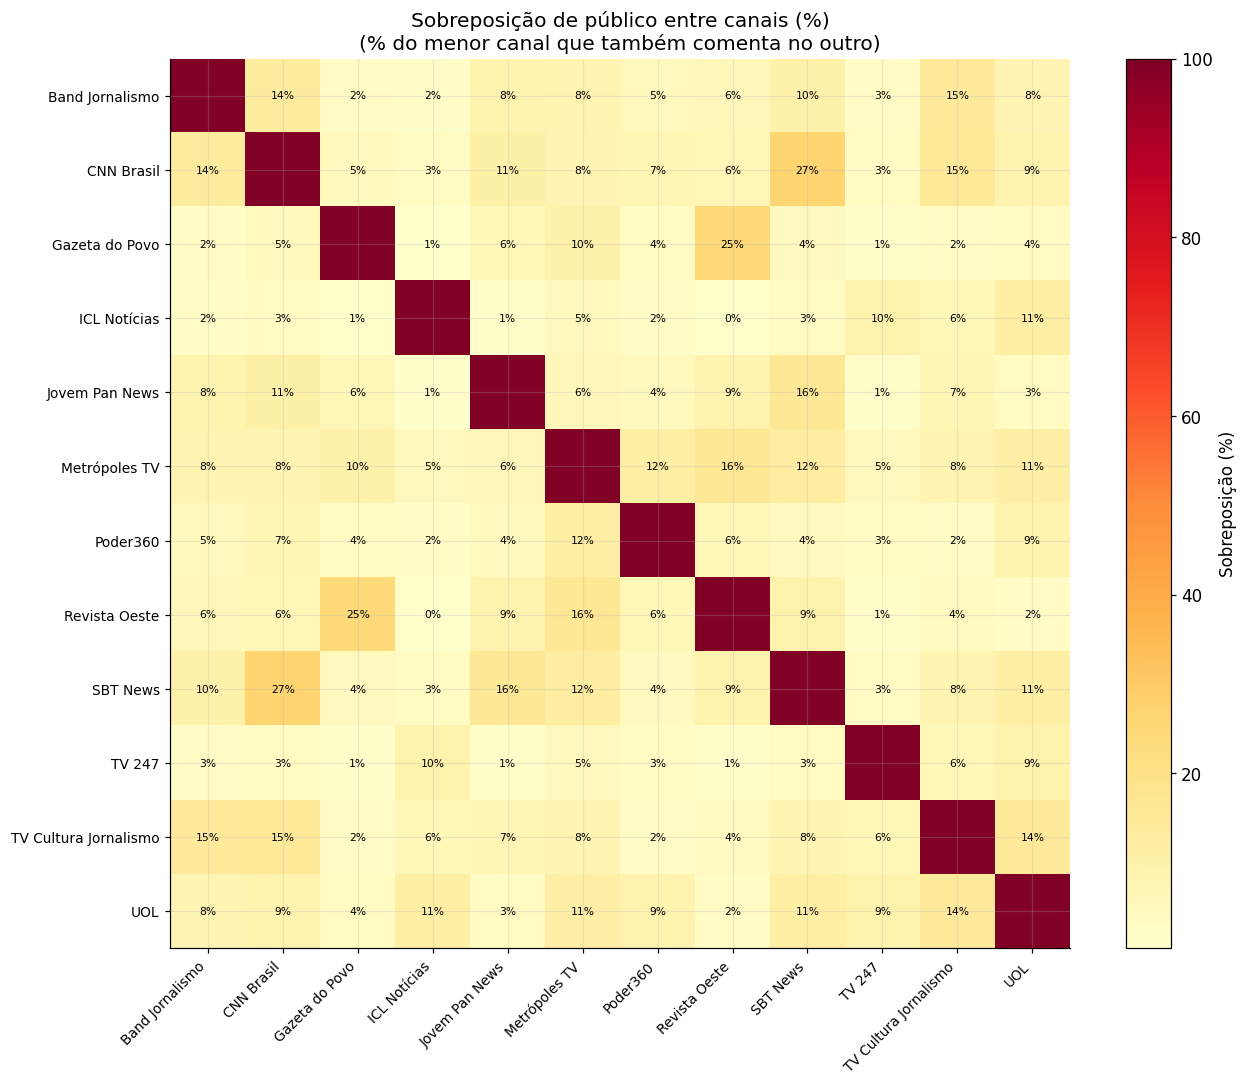


Top 10 pares de canais com maior sobreposição de público:
  CNN Brasil               × SBT News                 →  1,012 autores em comum (26.7%)
  Gazeta do Povo           × Revista Oeste            →  1,866 autores em comum (24.8%)
  Metrópoles TV            × Revista Oeste            →  2,587 autores em comum (16.3%)
  Jovem Pan News           × SBT News                 →    596 autores em comum (15.7%)
  CNN Brasil               × TV Cultura Jornalismo    →    174 autores em comum (15.0%)
  Band Jornalismo          × TV Cultura Jornalismo    →    169 autores em comum (14.6%)
  TV Cultura Jornalismo    × UOL                      →    168 autores em comum (14.5%)
  Band Jornalismo          × CNN Brasil               →    793 autores em comum (13.6%)
  Metrópoles TV            × SBT News                 →    463 autores em comum (12.2%)
  Metrópoles TV            × Poder360                 →    535 autores em comum (11.6%)


In [5]:
msgs_au = load('messages', columns=['video_id', 'author_channel_hash']).dropna()
msgs_au['canal'] = msgs_au['video_id'].map(vid2ch).map(name_map)
msgs_au = msgs_au.dropna(subset=['canal'])

# Autores únicos por canal
autores_por_canal = msgs_au.groupby('canal')['author_channel_hash'].apply(set)

# Matriz de sobreposição
canais_list = sorted(autores_por_canal.index)
n = len(canais_list)
overlap_matrix = np.zeros((n, n))

for i, c1 in enumerate(canais_list):
    for j, c2 in enumerate(canais_list):
        s1 = autores_por_canal[c1]
        s2 = autores_por_canal[c2]
        if i == j:
            overlap_matrix[i][j] = len(s1)
        else:
            overlap_matrix[i][j] = len(s1 & s2)

# Percentual: overlap / min(len(s1), len(s2))
pct_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            pct_matrix[i][j] = 100
        else:
            mn = min(overlap_matrix[i][i], overlap_matrix[j][j])
            pct_matrix[i][j] = round(overlap_matrix[i][j] / mn * 100, 1) if mn > 0 else 0

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(pct_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(canais_list, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(canais_list, fontsize=9)

# Anotar valores
for i in range(n):
    for j in range(n):
        val = pct_matrix[i][j]
        if i != j and val > 0:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7,
                    color='white' if val > 30 else 'black')

ax.set_title('Sobreposição de público entre canais (%)\n(% do menor canal que também comenta no outro)')
plt.colorbar(im, ax=ax, label='Sobreposição (%)')
plt.tight_layout(); plt.show()

# Top pares de canais com maior sobreposição
pares = []
for i in range(n):
    for j in range(i+1, n):
        pares.append((canais_list[i], canais_list[j], int(overlap_matrix[i][j]), pct_matrix[i][j]))
pares.sort(key=lambda x: -x[3])
print('\nTop 10 pares de canais com maior sobreposição de público:')
for c1, c2, total, pct in pares[:10]:
    print(f'  {c1:24s} × {c2:24s} → {total:>6,} autores em comum ({pct:.1f}%)')

del msgs_au  # liberar memória

---
## Insight 4 — Picos de spam / "raids"

Detecta minutos com explosão de mensagens repetidas (mesmo texto),
indicando bots, raids ou spam organizado.

Carregando mensagens com texto (pode demorar)...
Mensagens com texto carregadas: 2,332,001

Minutos com spam detectados: 6,756


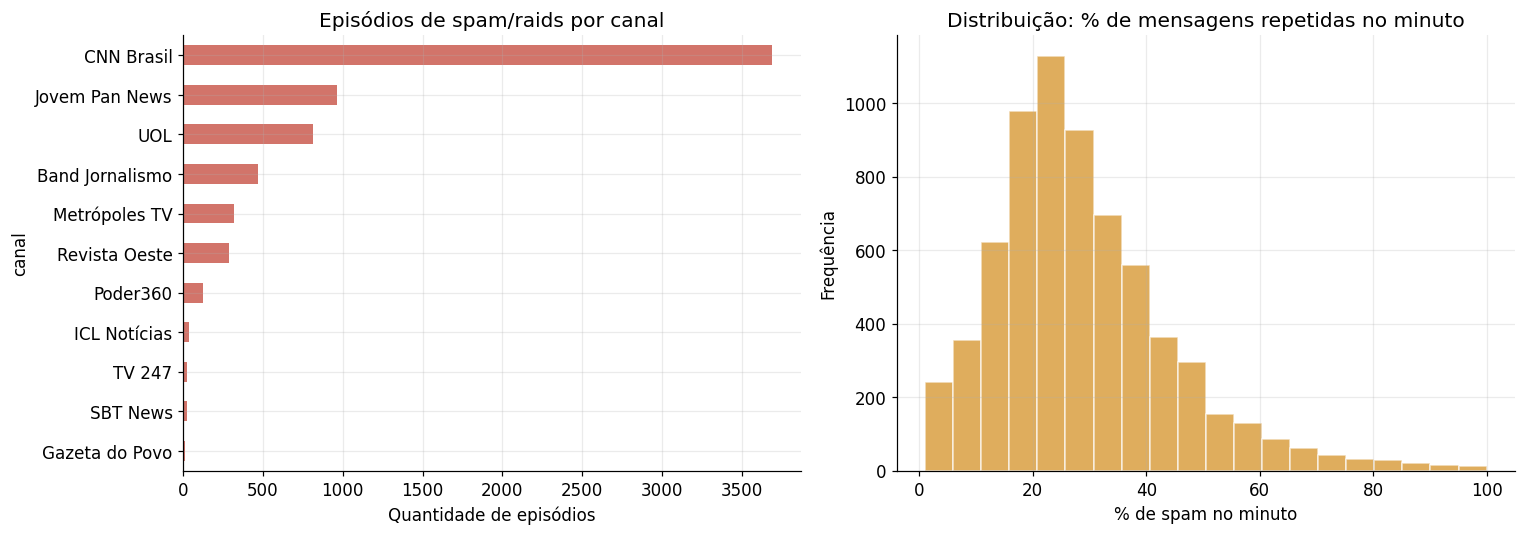


Top 10 episódios de spam mais intensos:
  [UOL                 ] min  91 | 181x/262 msgs (69.1%) | "L"
  [UOL                 ] min  92 | 146x/229 msgs (63.8%) | "L"
  [TV 247              ] min   8 | 132x/157 msgs (84.1%) | "1"
  [CNN Brasil          ] min  15 | 121x/204 msgs (59.3%) | "22"
  [UOL                 ] min  93 | 120x/244 msgs (49.2%) | "L"
  [TV 247              ] min   9 | 89x/115 msgs (77.4%) | "1"
  [UOL                 ] min  94 | 85x/211 msgs (40.3%) | "L"
  [Poder360            ] min  20 | 85x/310 msgs (27.4%) | "14"
  [UOL                 ] min 151 | 76x/171 msgs (44.4%) | "SERGIO"
  [UOL                 ] min  90 | 69x/146 msgs (47.3%) | "L"


In [6]:
# Carregar texto das mensagens (pode demorar — ~110MB)
print('Carregando mensagens com texto (pode demorar)...')
msgs_text = load('messages', columns=['video_id', 'video_offset_ms', 'text'])
msgs_text = msgs_text.dropna(subset=['text', 'video_offset_ms'])
msgs_text['minuto'] = (msgs_text['video_offset_ms'] / 60000).astype(int)
msgs_text['canal'] = msgs_text['video_id'].map(vid2ch).map(name_map)
print(f'Mensagens com texto carregadas: {len(msgs_text):,}')

# Detectar minutos com muitas mensagens repetidas
def detectar_spam(df, limiar_repeticoes=10):
    """Encontra minutos com alto volume de mensagens repetidas."""
    resultados = []
    for (vid, minuto), grupo in df.groupby(['video_id', 'minuto']):
        if len(grupo) < 5:
            continue
        contagem = grupo['text'].value_counts()
        top_msg = contagem.iloc[0]
        top_texto = contagem.index[0]
        if top_msg >= limiar_repeticoes:
            canal = vid2ch.get(vid, '')
            resultados.append({
                'video_id': vid,
                'canal': ch_name(canal),
                'minuto': minuto,
                'total_msgs': len(grupo),
                'msg_repetida': top_texto[:80],
                'repeticoes': top_msg,
                'pct_spam': round(top_msg / len(grupo) * 100, 1)
            })
    return pd.DataFrame(resultados)

df_spam = detectar_spam(msgs_text)
print(f'\nMinutos com spam detectados: {len(df_spam):,}')

if not df_spam.empty:
    # Distribuição de spam por canal
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Contagem de episódios de spam por canal
    spam_por_canal = df_spam.groupby('canal').size().sort_values(ascending=True)
    spam_por_canal.plot(kind='barh', ax=axes[0], color=RED, alpha=0.7)
    axes[0].set_title('Episódios de spam/raids por canal')
    axes[0].set_xlabel('Quantidade de episódios')

    # Gráfico 2: Distribuição do % de spam
    axes[1].hist(df_spam['pct_spam'], bins=20, color=AMBER, alpha=0.7, edgecolor='white')
    axes[1].set_title('Distribuição: % de mensagens repetidas no minuto')
    axes[1].set_xlabel('% de spam no minuto')
    axes[1].set_ylabel('Frequência')

    plt.tight_layout(); plt.show()

    print('\nTop 10 episódios de spam mais intensos:')
    top_spam = df_spam.sort_values('repeticoes', ascending=False).head(10)
    for _, row in top_spam.iterrows():
        print(f'  [{row["canal"]:20s}] min {row["minuto"]:>3} | '
              f'{row["repeticoes"]}x/{row["total_msgs"]} msgs ({row["pct_spam"]}%) '
              f'| "{row["msg_repetida"]}"')

---
## Insight 5 — Evolução temática no tempo

Repete a análise de termos over-indexados da Seção 9 do notebook 1, mas por **semana**,
para ver quais assuntos subiram ou caíram ao longo do período.

Processando transcrições por semana (pode demorar)...


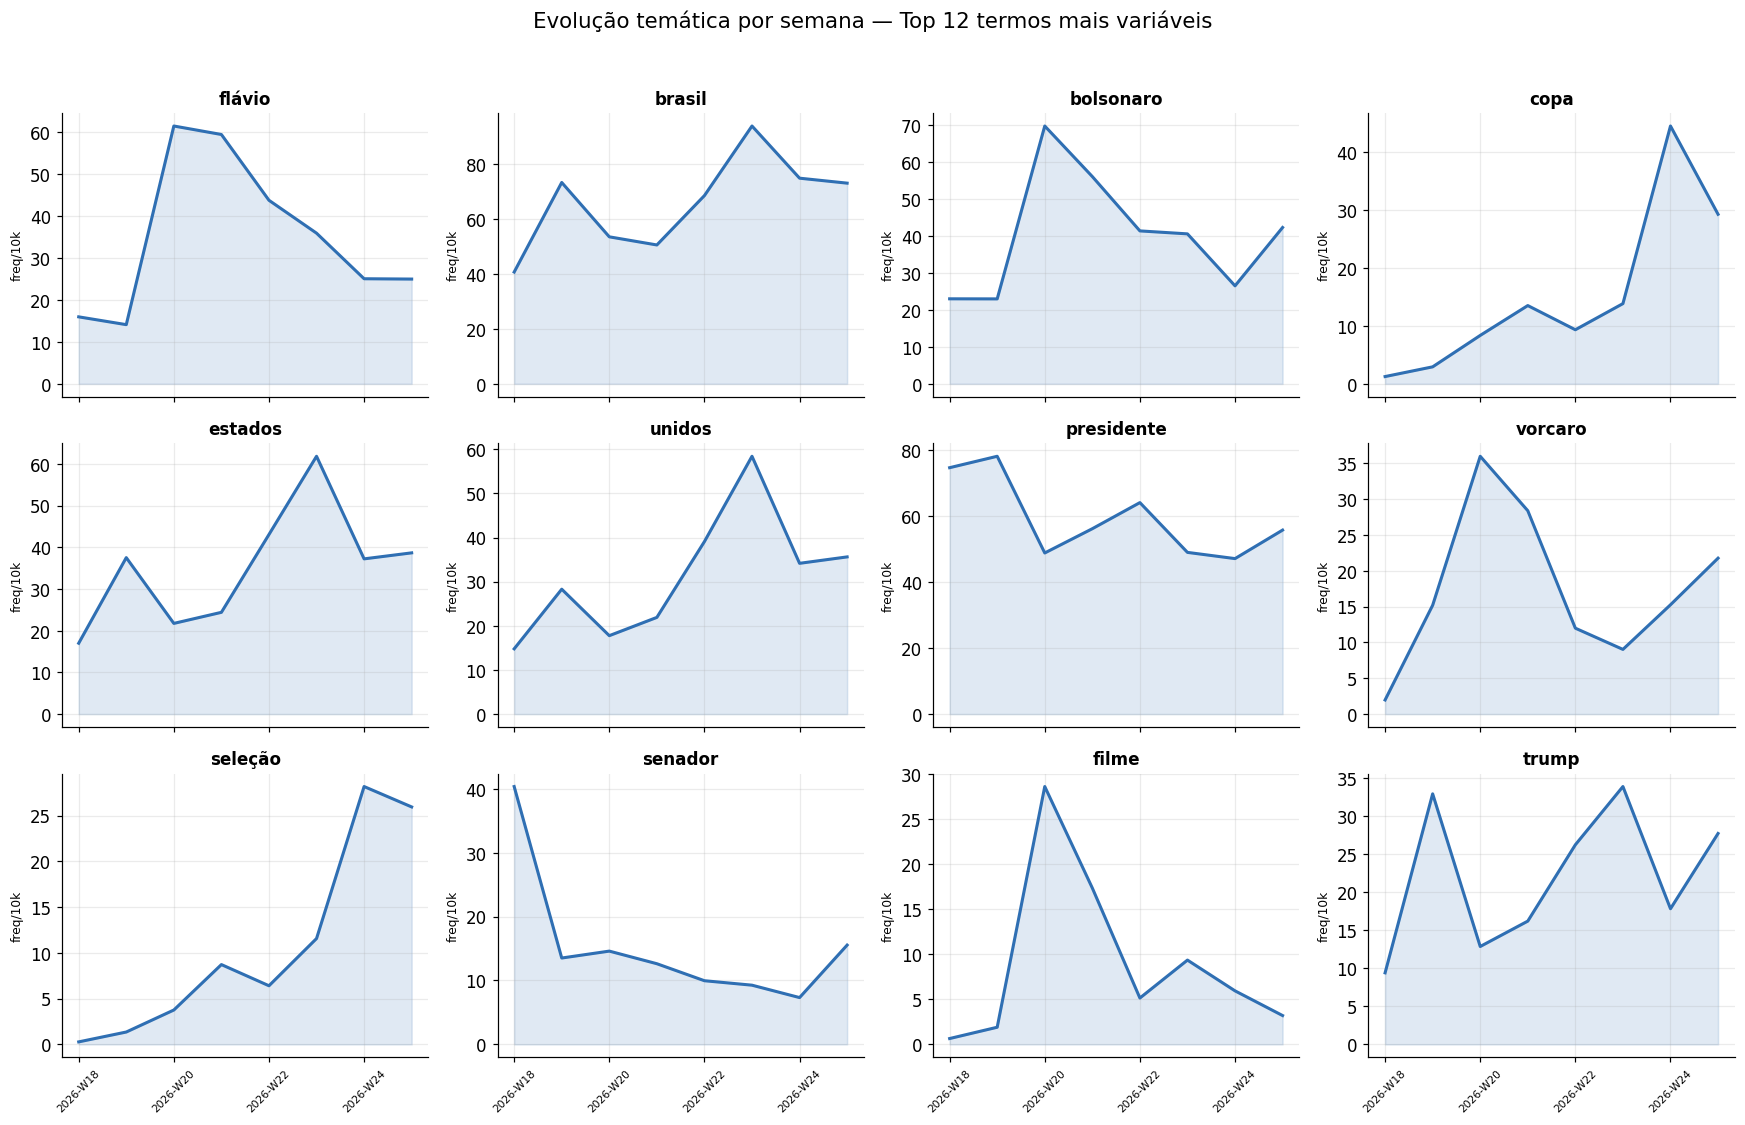

In [8]:
STOP = set('''a o e que de do da em um uma os as dos das no na nos nas ao à aos às por para com se sua seu suas
seus eu você ele ela nós eles elas me te lhe nos vos lhes meu minha isso isto aquilo este esta esse essa aquele
aquela não sim mais menos muito pouco já ainda também só apenas então porque pois como quando onde quem qual quais
ser estar ter haver ir vir ver dar fazer poder dizer falar saber querer dever ficar passar quero queria é são foi
era estão está sendo tem têm tinha houve vai vão vamos vou seria seriam pode podem podia aqui ali lá cá agora hoje
ontem amanhã sempre nunca tudo nada algo alguém ninguém cada todo toda todos todas bem bom boa né tá pra pro pros
pras cê tô vamo olha assim coisa coisas gente vez vezes dia dias ano anos mas ou nem porém contudo entretanto sobre
entre até desde após antes depois durante contra sob num numa isso aqui aí oh ah eh uhm hum tipo cara meio super
bastante realmente verdade certo nesse neste dessa música aplausos risos inaudível aplauso vinheta the to of and in
is are this that you we for with people be on it as quer dizer ó deu fica fazendo falando dizendo dando indo vindo
vendo fala falar falou disse dito acho acha achar parece momento questão sentido caso casos lado parte forma maneira
ponto vista pessoal galera inscreva canal vídeo live vivo obrigado obrigada primeiro segunda grande grandes melhor
pior maior dentro fora pouco tanto tão outro outra outros outras mesmo mesma mesmos muita muitos muitas dois duas
três pelo pela seja esses essas dele dela deles delas nosso nossa nossos nossas temos sabe vocês inclusive desse
senhor coisa precisa fazer feito sendo aqui pessoas tempo trabalho'''.split())

tok = re.compile(r'[a-zà-úâ-ûãõç]{4,}')

# Contar termos por semana
semana_counts = defaultdict(Counter)
overall_sem = Counter()

# Mapear video_id -> semana (usando actual_start)
vid_start = videos.set_index('video_id')['actual_start'].to_dict()

pf = pq.ParquetFile(path('transcripts'))
print('Processando transcrições por semana (pode demorar)...')
for batch in pf.iter_batches(batch_size=40, columns=['video_id', 'text']):
    for vid, txt in zip(batch.column('video_id').to_pylist(), batch.column('text').to_pylist()):
        if not txt:
            continue
        start = vid_start.get(vid)
        if pd.isna(start) or start <= 0:
            continue
        dt = pd.Timestamp(start, unit='s')
        if pd.isna(dt): # Proteção extra para garantir que não é NaT
            continue
        semana = dt.strftime('%Y-W%V')

        for w in tok.findall(txt.lower()):
            if w not in STOP:
                semana_counts[semana][w] += 1
                overall_sem[w] += 1

# Selecionar termos frequentes
vocab_freq = {w for w, c in overall_sem.most_common(200)}

# Montar DataFrame semana × termo (frequência relativa)
semanas_ord = sorted(semana_counts.keys())
dados_evo = {}
for sem in semanas_ord:
    total = sum(semana_counts[sem].values())
    if total < 1000:
        continue
    for w in vocab_freq:
        freq = semana_counts[sem].get(w, 0) / total * 10000  # por 10k palavras
        if w not in dados_evo:
            dados_evo[w] = {}
        dados_evo[w][sem] = freq

df_evo = pd.DataFrame(dados_evo).fillna(0)

# Encontrar termos que mais variaram (desvio padrão alto)
variacao = df_evo.std().sort_values(ascending=False)
top_termos = variacao.head(12).index.tolist()

# Plotar evolução dos top termos
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True)
for i, termo in enumerate(top_termos):
    ax = axes[i // 4][i % 4]
    ax.plot(range(len(df_evo)), df_evo[termo], color=BLUE, linewidth=2)
    ax.fill_between(range(len(df_evo)), df_evo[termo], alpha=0.15, color=BLUE)
    ax.set_title(termo, fontsize=11, fontweight='bold')
    ax.set_xticks(range(0, len(df_evo), max(1, len(df_evo)//4)))
    ax.set_xticklabels([df_evo.index[j] for j in range(0, len(df_evo), max(1, len(df_evo)//4))],
                       rotation=45, fontsize=7)
    ax.set_ylabel('freq/10k', fontsize=8)

fig.suptitle('Evolução temática por semana — Top 12 termos mais variáveis', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## Insight 6 — Análise de emojis e sentimento do chat

Extrai emojis do texto das mensagens e mede o "tom" por canal usando
listas simples de palavras positivas/negativas em português.

Top 5 emojis por canal:

  Band Jornalismo         : 🇧🇷(6,360)  🤷🏾(4,256)  👉🏾(1,613)  🇱🇷(668)  🤷🏾🤷🏾(409)
  CNN Brasil              : 🇧🇷(32,226)  👉🏻(5,153)  🇺🇲(4,591)  🇺🇸(4,408)  🙏🏻(3,746)
  Gazeta do Povo          : 🇧🇷(2,191)  🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷(235)  🇧🇷🇧🇷(140)  🇧🇷🇧🇷🇧🇷(138)  🇺🇸(108)
  ICL Notícias            : 🇧🇷(911)  🇧🇷🇧🇷🇧🇷(92)  👏🏻👏🏻👏🏻(54)  🇺🇸(45)  🙌🏾(37)
  Jovem Pan News          : 🇧🇷(17,350)  🇺🇸(1,673)  ♂(1,046)  🤷🏾(818)  ♂🤷🏾(812)
  Metrópoles TV           : 🇧🇷(7,949)  🇧🇷🇧🇷🇧🇷(880)  🇧🇷🇧🇷(457)  👍🏻(443)  🇧🇷🇧🇷🇧🇷🇧🇷(371)
  Poder360                : 🇧🇷(3,423)  ☆(620)  🇧🇷🇧🇷🇧🇷(317)  👈🏻(196)  🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷(101)
  Revista Oeste           : 🇧🇷(17,744)  🇧🇷🇧🇷🇧🇷(1,509)  🇧🇷🇧🇷(1,359)  🇧🇷🇧🇷🇧🇷🇧🇷(981)  🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷(645)
  SBT News                : 👉🏻(1,114)  🇧🇷(868)  🇧🇷🇧🇷🇧🇷(350)  🇧🇷🇮🇱🇺🇲🇺🇲(256)  👈🏻(117)
  TV 247                  : 🇧🇷(2,943)  🇵🇸(1,129)  🇵🇪(282)  ⚘(247)  🇺🇸(199)
  TV Cultura Jornalismo   : 🤷🏾(287)  🇧🇷(252)  👉🏾(171)  🇺🇸(49)  🇮🇹(39)
  UOL                     : 🇧🇷(4,269)  ♂(629)  🇧🇷🇧🇷(572)  🤷🏾

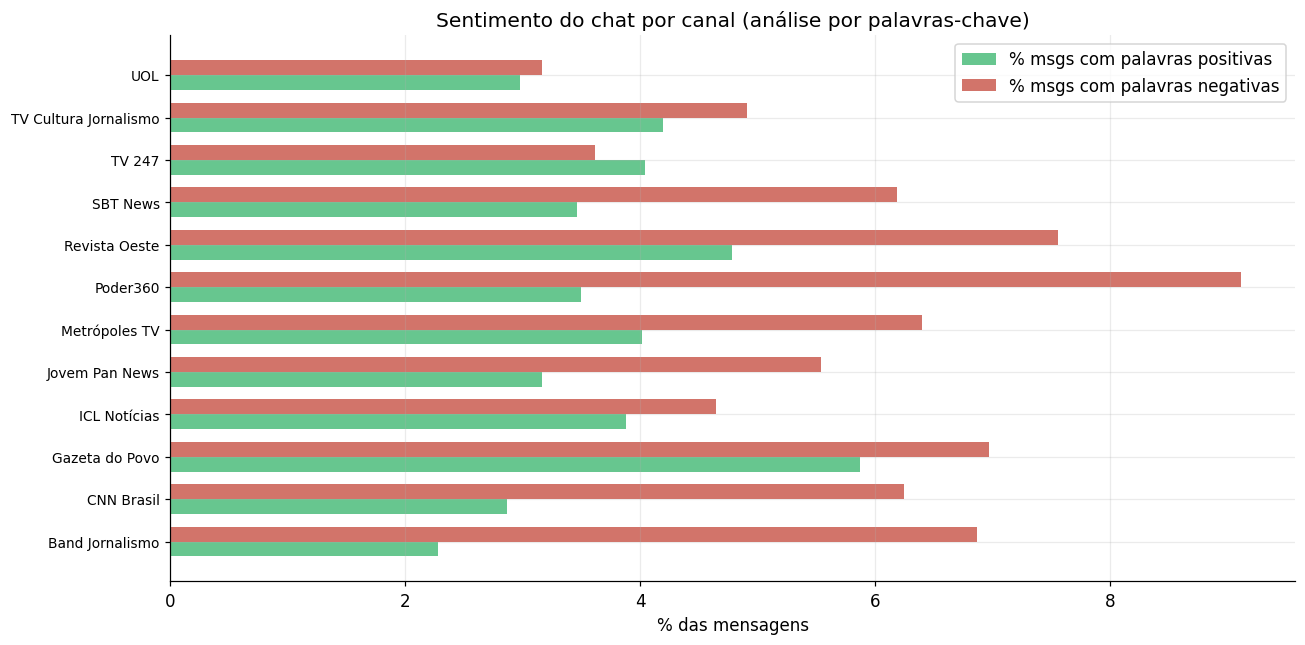

In [9]:
# Regex para emojis Unicode
emoji_re = re.compile(
    '[\U0001F600-\U0001F64F'  # emoticons
    '\U0001F300-\U0001F5FF'   # símbolos & pictogramas
    '\U0001F680-\U0001F6FF'   # transporte & mapa
    '\U0001F1E0-\U0001F1FF'   # flags
    '\U00002702-\U000027B0'
    '\U0001F900-\U0001F9FF'   # supplemental
    '\U0001FA00-\U0001FA6F'
    '\U0001FA70-\U0001FAFF'
    '\U00002600-\U000026FF'   # misc
    ']+', flags=re.UNICODE
)

# Palavras de sentimento simples (PT-BR)
POSITIVAS = set('parabéns excelente ótimo maravilhoso incrível fantástico bravo show top demais '
                'sensacional perfeito adorei amei melhor lindo massa nota mito lacrou arrasou '
                'sucesso verdade apoio concordo correto certo justo merece'.split())
NEGATIVAS = set('vergonha absurdo ridículo péssimo horrível terrível mentira nojo lixo pior '
                'errado injusto golpe traição corrupto criminoso ladrão bandido fora impeachment '
                'desgraça horror covarde hipócrita falsidade mentiroso'.split())

# Analisar mensagens (já carregadas acima em msgs_text)
emoji_counts_canal = defaultdict(Counter)
sent_canal = defaultdict(lambda: {'pos': 0, 'neg': 0, 'total': 0})

for _, row in msgs_text.iterrows():
    canal = row.get('canal')
    texto = row.get('text', '')
    if not canal or not isinstance(texto, str):
        continue

    # Emojis
    emojis = emoji_re.findall(texto)
    for e in emojis:
        emoji_counts_canal[canal][e] += 1

    # Sentimento simples
    palavras = set(texto.lower().split())
    pos = len(palavras & POSITIVAS)
    neg = len(palavras & NEGATIVAS)
    sent_canal[canal]['pos'] += pos
    sent_canal[canal]['neg'] += neg
    sent_canal[canal]['total'] += 1

# Top emojis por canal
print('Top 5 emojis por canal:\n')
for canal in sorted(emoji_counts_canal):
    top5 = emoji_counts_canal[canal].most_common(5)
    emojis_str = '  '.join(f'{e}({c:,})' for e, c in top5)
    print(f'  {canal:24s}: {emojis_str}')

# Gráfico de sentimento
canais_sent = sorted(sent_canal.keys())
pos_rates = [(sent_canal[c]['pos'] / sent_canal[c]['total'] * 100) if sent_canal[c]['total'] > 0 else 0
             for c in canais_sent]
neg_rates = [(sent_canal[c]['neg'] / sent_canal[c]['total'] * 100) if sent_canal[c]['total'] > 0 else 0
             for c in canais_sent]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(canais_sent))
w = 0.35
ax.barh(x - w/2, pos_rates, w, label='% msgs com palavras positivas', color=GREEN, alpha=0.7)
ax.barh(x + w/2, neg_rates, w, label='% msgs com palavras negativas', color=RED, alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(canais_sent, fontsize=9)
ax.set_xlabel('% das mensagens')
ax.set_title('Sentimento do chat por canal (análise por palavras-chave)')
ax.legend()
plt.tight_layout(); plt.show()

---
## Insight 7 — Funil de conteúdo

Análise do ciclo de vida das lives: agendada → ao vivo → concluída.
Usa `live_status` e campos de timing em `videos` para mapear o funil.

Status das lives:
live_status
was_live       2154
post_live       462
unknown          99
is_upcoming      78
is_live           4



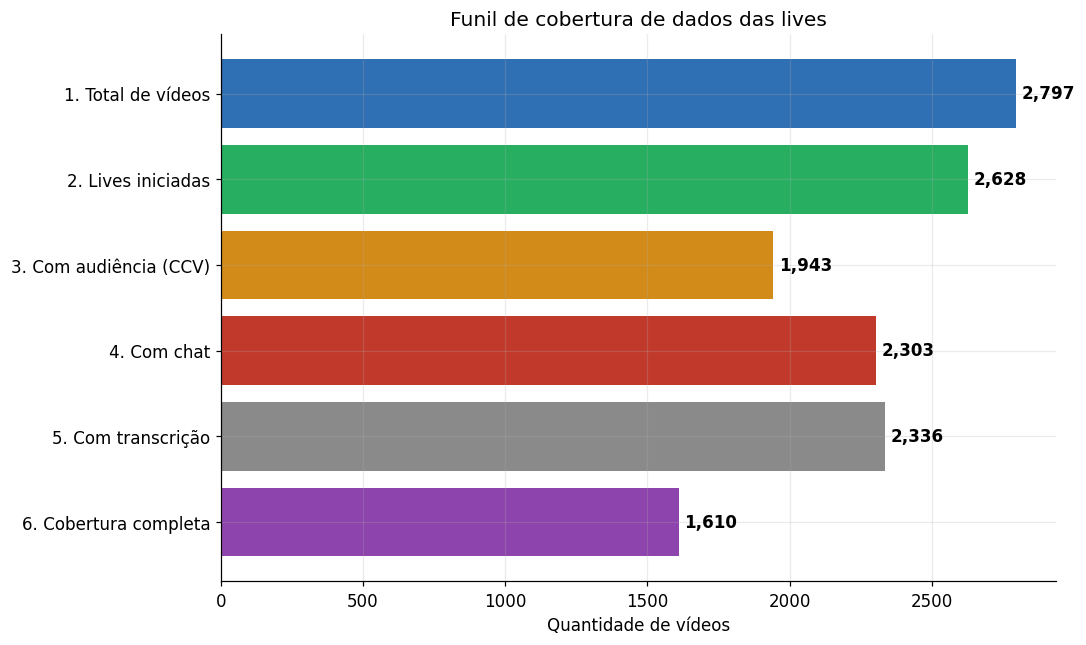

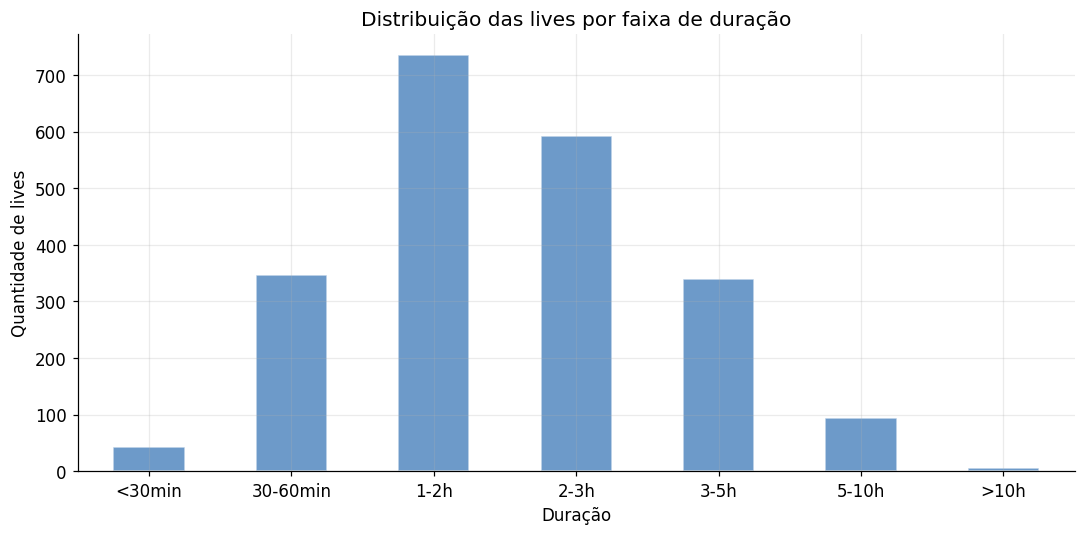


Distribuição por faixa de duração:
faixa_duracao
<30min       43
30-60min    347
1-2h        735
2-3h        593
3-5h        339
5-10h        94
>10h          5


In [10]:
# Analisar status das lives
if 'live_status' in videos.columns:
    status_counts = videos['live_status'].value_counts()
    print('Status das lives:')
    print(status_counts.to_string())
    print()

# Funil: vídeos com actual_start > 0, com ccv, com mensagens, com transcrições
ids_all = set(videos['video_id'])
ids_started = set(videos[videos['actual_start'] > 0]['video_id'])
ids_ccv = set(ccv['video_id'])
ids_msg = set(msgs_text['video_id'])
ids_trs = set(load('transcripts', columns=['video_id'])['video_id'])

funil = pd.DataFrame([
    {'Etapa': '1. Total de vídeos', 'Quantidade': len(ids_all)},
    {'Etapa': '2. Lives iniciadas', 'Quantidade': len(ids_started)},
    {'Etapa': '3. Com audiência (CCV)', 'Quantidade': len(ids_started & ids_ccv)},
    {'Etapa': '4. Com chat', 'Quantidade': len(ids_started & ids_msg)},
    {'Etapa': '5. Com transcrição', 'Quantidade': len(ids_started & ids_trs)},
    {'Etapa': '6. Cobertura completa', 'Quantidade': len(ids_started & ids_ccv & ids_msg & ids_trs)},
])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(funil['Etapa'], funil['Quantidade'], color=[BLUE, GREEN, AMBER, RED, GRAY, '#8e44ad'])
for bar, val in zip(bars, funil['Quantidade']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Quantidade de vídeos')
ax.set_title('Funil de cobertura de dados das lives')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Análise de duração por faixa
videos_validos = videos[videos['duration_seconds'] > 0].copy()
videos_validos['duracao_min'] = videos_validos['duration_seconds'] / 60
bins = [0, 30, 60, 120, 180, 300, 600, 1440]
labels = ['<30min', '30-60min', '1-2h', '2-3h', '3-5h', '5-10h', '>10h']
videos_validos['faixa_duracao'] = pd.cut(videos_validos['duracao_min'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 5))
videos_validos['faixa_duracao'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=BLUE, alpha=0.7, edgecolor='white')
ax.set_title('Distribuição das lives por faixa de duração')
ax.set_xlabel('Duração')
ax.set_ylabel('Quantidade de lives')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

print('\nDistribuição por faixa de duração:')
print(videos_validos['faixa_duracao'].value_counts().sort_index().to_string())

---
## Conclusão

Este notebook complementar implementou os 7 insights e o que observamos:
